## AVIATION ANALYSIS

Business Understanding
1. Problem Statement

The aviation industry has experienced numerous accidents over the past several decades, ranging from minor incidents to complete aircraft destruction and loss of life.

Airlines and insurers are particularly interested in understanding which aircraft makes and models are associated with higher or lower risks of catastrophic failure and passenger injury.

This project uses aviation accident data (1983–2023, filtered for modern professional aircraft) to identify patterns in aircraft safety, focusing on fatal/serious injuries and aircraft destruction outcomes.

The goal is to support data-driven decision-making for aircraft selection and insurance risk assessment.

2. Metric of Success

The success of this project will be determined by:

Identifying aircraft makes and models with consistently low injury rates
Identifying aircraft with low likelihood of being destroyed in accidents
Producing statistically reliable comparisons based on sufficient sample sizes (≥ 50 incidents per make)
Understanding key factors that influence accident severity (e.g. weather, engine type, flight phase)

3. Specific Objective
To identify aircraft makes and models associated with low fatal and serious injury rates
To determine which aircraft types are most resistant to complete destruction in accidents
To support insurers and airlines in selecting lower-risk aircraft for operations and investment

4. Other Objectives
To determine whether certain aircraft makes perform better than others in safety outcomes
To analyze how weather conditions influence accident severity
To assess the impact of flight phase (takeoff, landing, cruise, etc.) on accident outcomes
To compare safety differences between small aircraft and larger passenger aircraft
To explore whether engine type or number of engines affects survival outcomes

5. Research Questions

a. Which aircraft makes and models have the lowest injury rates and destruction rates?

b. What aircraft characteristics (make, model, engine type, number of engines) are associated with safer outcomes?

c. How does weather condition affect the severity of aviation accidents?

d. Which phase of flight is most associated with fatal or serious injuries?

e. Are larger passenger aircraft safer than smaller aircraft in terms of survival outcomes?

Data Understanding

The dataset contains historical aviation accident records from 1948 to 2023, detailing aircraft incidents, passenger outcomes, and operational conditions. For this analysis, the dataset was filtered to include only modern, professionally built aircraft (1983 onwards) to ensure relevance to current aviation safety standards.

Each row represents a single aviation accident event and includes information about:

Aircraft characteristics (make, model, engine type, number of engines)
Operational conditions (weather, flight phase, purpose of flight)
Accident outcomes (fatal, serious, minor injuries, aircraft damage)
Passenger survival information
Key Variables in the Dataset
Aircraft Information
Make – Manufacturer of the aircraft (e.g., Boeing, Cessna)
Model – Specific aircraft model
Aircraft.Category – Type of aircraft (filtered to Airplane only)
Engine.Type – Type of propulsion system
Number.of.Engines – Number of engines installed
Accident Outcome Variables
Total.Fatal.Injuries – Number of deaths
Total.Serious.Injuries – Serious injuries sustained
Total.Minor.Injuries – Minor injuries sustained
Total.Uninjured – Surviving passengers

From these, we derive:

total_passengers – Total people involved in the accident
injury_rate – Proportion of serious + fatal injuries
is_destroyed – Whether the aircraft was completely destroyed
Operational Conditions
Weather.Condition – Weather at time of accident (e.g., VMC, IMC)
Broad.phase.of.flight – Flight stage (takeoff, cruise, landing, etc.)
Purpose.of.flight – Reason for flight (commercial, private, etc.)


## Load Cleaned Data

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv('aviation_cleaned.csv', low_memory=False)
df['Number.of.Engines'] = pd.to_numeric(df['Number.of.Engines'], errors='coerce')

In [60]:
# Size classification: 1-engine = Small, 2+ engines = Large
df['size_class'] = None
df.loc[df['Number.of.Engines'] == 1, 'size_class'] = 'Small'
df.loc[df['Number.of.Engines'] >= 2, 'size_class'] = 'Large'

small = df[df['size_class'] == 'Small'].copy()
large = df[df['size_class'] == 'Large'].copy()

print(f'Total records: {len(df):,}')
print(f'Small (1-engine): {len(small):,}')
print(f'Large (2+ engines): {len(large):,}')
df.head(3)

Total records: 17,879
Small (1-engine): 13,222
Large (2+ engines): 2,563


,Make,Number.of.Engines,Weather.Condition,Broad.phase.of.flight,total_passengers,injury_rate,is_destroyed,Make_Model,size_class
0,Boeing,4.0000,VMC,Taxi,588.0000,0.0000,0.0000,Boeing — 747,Large
1,Piper,1.0000,IMC,Cruise,2.0000,1.0000,1.0000,Piper — PA-28-140,Small
2,De Havilland,2.0000,VMC,Standing,5.0000,0.2000,NaN,De Havilland — DHC-6,Large


## Safety Metrics Across Makes and Models

### Top-15 Makes — Mean Fatal/Serious Injury Rate

In [61]:
def make_injury_stats(sub, min_n=10):
    return sub.groupby('Make').agg(
        n=('injury_rate', 'count'),
        mean_inj=('injury_rate', 'mean')
    ).query(f'n >= {min_n}').sort_values('mean_inj')

sm15 = make_injury_stats(small).head(15)
lg15 = make_injury_stats(large).head(15)

print('Small Aircraft — Top 15 Lowest Injury Rate Makes')
print(sm15)
print('\nLarge Aircraft — Top 15 Lowest Injury Rate Makes')
print(lg15)

Small Aircraft — Top 15 Lowest Injury Rate Makes
                                   n  mean_inj
Make                                          
Maule                            205    0.1594
Rockwell International            43    0.1667
Aviat Aircraft Inc                75    0.1667
Boeing                           106    0.1808
Grumman Acft Eng Cor-Schweizer    55    0.2000
Ayres                             43    0.2093
Aviat                             69    0.2101
Stinson                          128    0.2129
Bellanca                         210    0.2155
Cessna                          5997    0.2246
Aeronca                          196    0.2279
Dehavilland                       80    0.2401
Champion                         145    0.2425
Diamond Aircraft Ind Inc          67    0.2463
Piper                           3237    0.2626

Large Aircraft — Top 15 Lowest Injury Rate Makes
                             n  mean_inj
Make                                    
Bombardier          

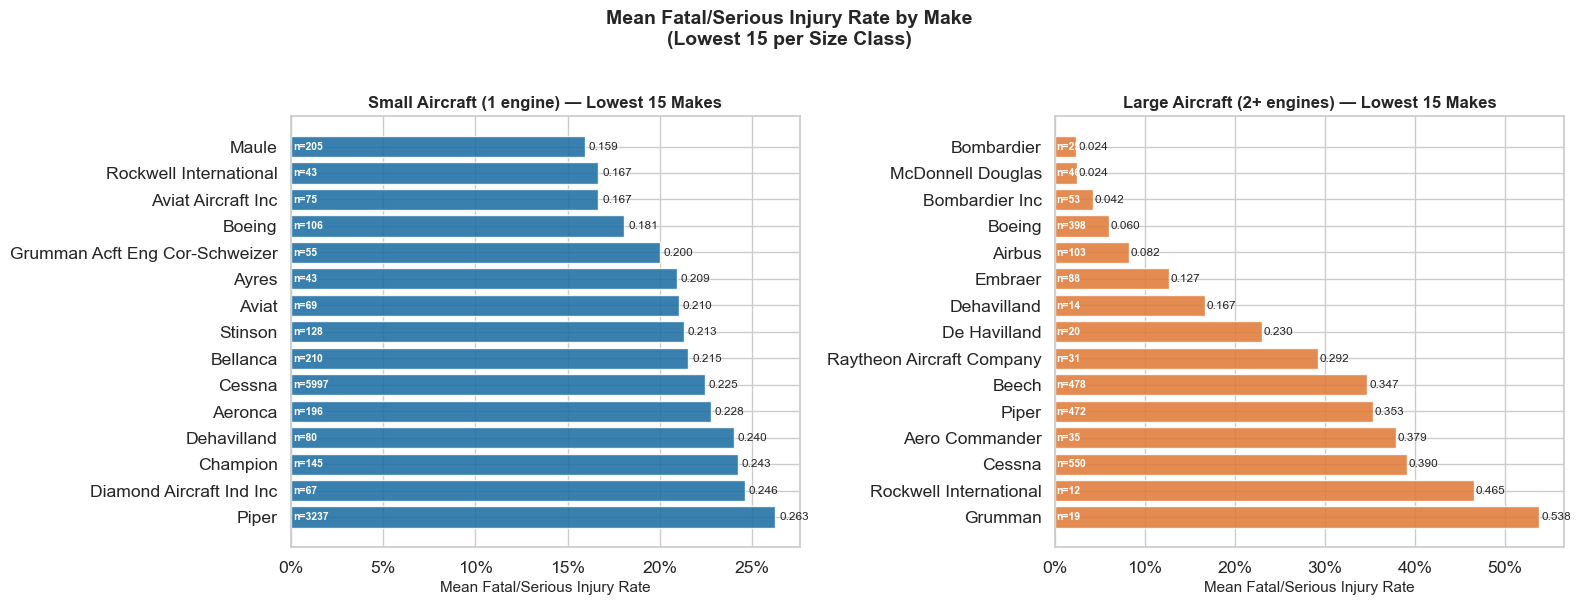

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ms, title, color in zip(axes,
        [sm15, lg15],
        ['Small Aircraft (1 engine) — Lowest 15 Makes',
         'Large Aircraft (2+ engines) — Lowest 15 Makes'],
        ['#1D6FA4', '#E07B39']):
    bars = ax.barh(ms.index[::-1], ms['mean_inj'][::-1],
                   color=color, edgecolor='white', alpha=0.88)
    
    ax.set_xlabel('Mean Fatal/Serious Injury Rate', fontsize=11)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    
    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8.5)
    
    for i, (make, row) in enumerate(ms[::-1].iterrows()):
        ax.text(0.001, i, f'n={int(row["n"])}',
                va='center', fontsize=7.5, color='white', fontweight='bold')

plt.suptitle('Mean Fatal/Serious Injury Rate by Make\n(Lowest 15 per Size Class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Violin Plot — Small Makes (10 Lowest Mean Injury Rate)

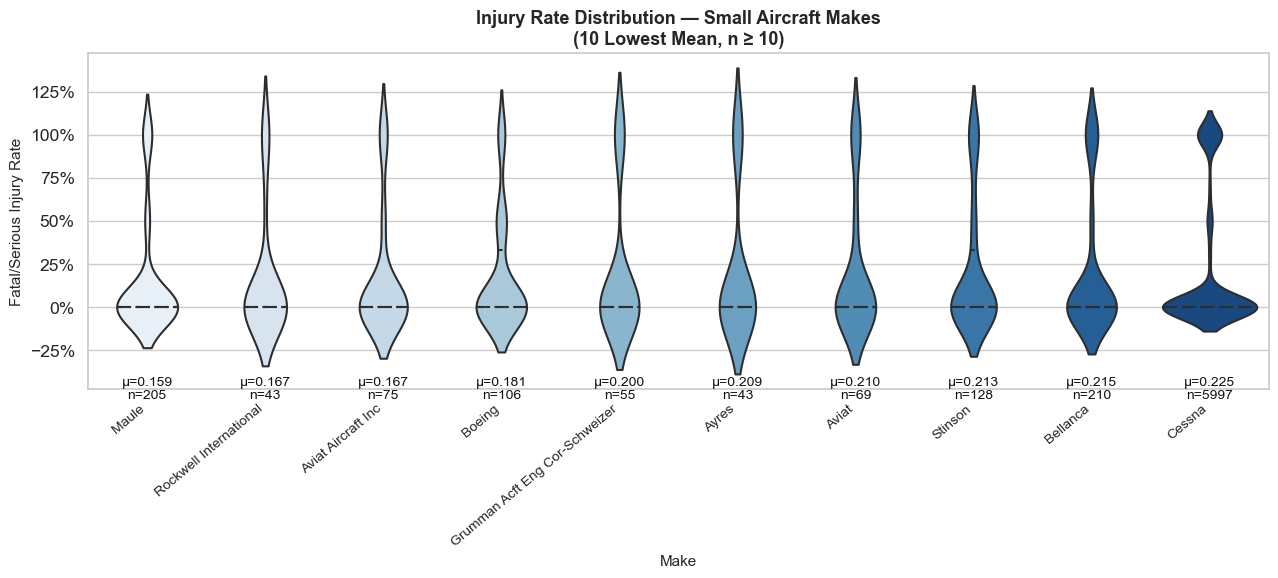

In [63]:
sm10 = make_injury_stats(small).head(10)
sm10_data = small[small['Make'].isin(sm10.index)].dropna(subset=['injury_rate'])
order_sm = sm10.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=sm10_data, x='Make', y='injury_rate', order=order_sm,
                palette='Blues', inner='quartile',
               density_norm='width', ax=ax)

ax.set_xticks(range(len(order_sm)))

ax.set_xticklabels(order_sm, rotation=40, ha='right', fontsize=10)

ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)

ax.set_xlabel('Make', fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_title('Injury Rate Distribution — Small Aircraft Makes\n(10 Lowest Mean, n ≥ 10)',
             fontsize=13, fontweight='bold')

for i, (make, row) in enumerate(sm10.iterrows()):
    ax.text(i, -0.4, f'μ={row["mean_inj"]:.3f}\nn={int(row["n"])}',
            ha='center', va='top', fontsize=10, color='#111')

plt.tight_layout()
plt.show()

### Strip Plot — Large Makes (10 Lowest Mean Injury Rate)

c:\Users\steve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\steve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


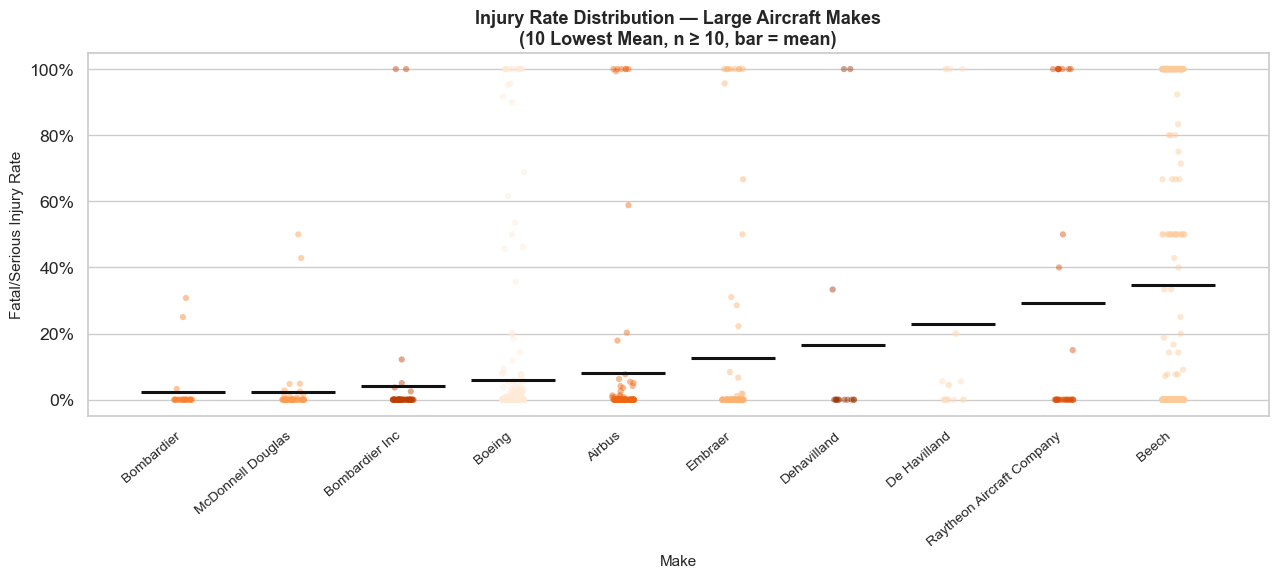

In [64]:
lg10 = make_injury_stats(large).head(10)
lg10_data = large[large['Make'].isin(lg10.index)].dropna(subset=['injury_rate'])
order_lg = lg10.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
sns.stripplot(data=lg10_data, x='Make', y='injury_rate', order=order_lg,
              hue='Make', palette='Oranges', alpha=0.45, size=4.5,
              jitter=True, legend=False, ax=ax)
for i, (make, row) in enumerate(lg10.iterrows()):
    ax.hlines(row['mean_inj'], i - 0.38, i + 0.38,
              colors='#111', linewidth=2.2, zorder=5)

ax.set_xticks(range(len(order_lg)))

ax.set_xticklabels(order_lg, rotation=40, ha='right', fontsize=10)

ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)

ax.set_xlabel('Make', fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_title('Injury Rate Distribution — Large Aircraft Makes\n(10 Lowest Mean, n ≥ 10, bar = mean)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Aircraft Destruction Rate by Make (Lowest 15)

=== Small Aircraft — Lowest 15 Destruction Rates ===
                                   n  dest_rate
Make                                           
Grumman Acft Eng Cor-Schweizer    55     0.0000
Boeing                           103     0.0097
Luscombe                         135     0.0148
Stinson                          128     0.0156
Taylorcraft                       89     0.0337
Aeronca                          196     0.0357
Maule                            205     0.0390
Aviat Aircraft Inc                74     0.0405
American Champion Aircraft        48     0.0417
Ercoupe                           48     0.0417
Bellanca                         210     0.0429
Rockwell International            43     0.0465
Dehavilland                       78     0.0513
Diamond Aircraft Ind Inc          67     0.0597
Cessna                          5965     0.0640

=== Large Aircraft — Lowest 15 Destruction Rates ===
                             n  dest_rate
Make                               

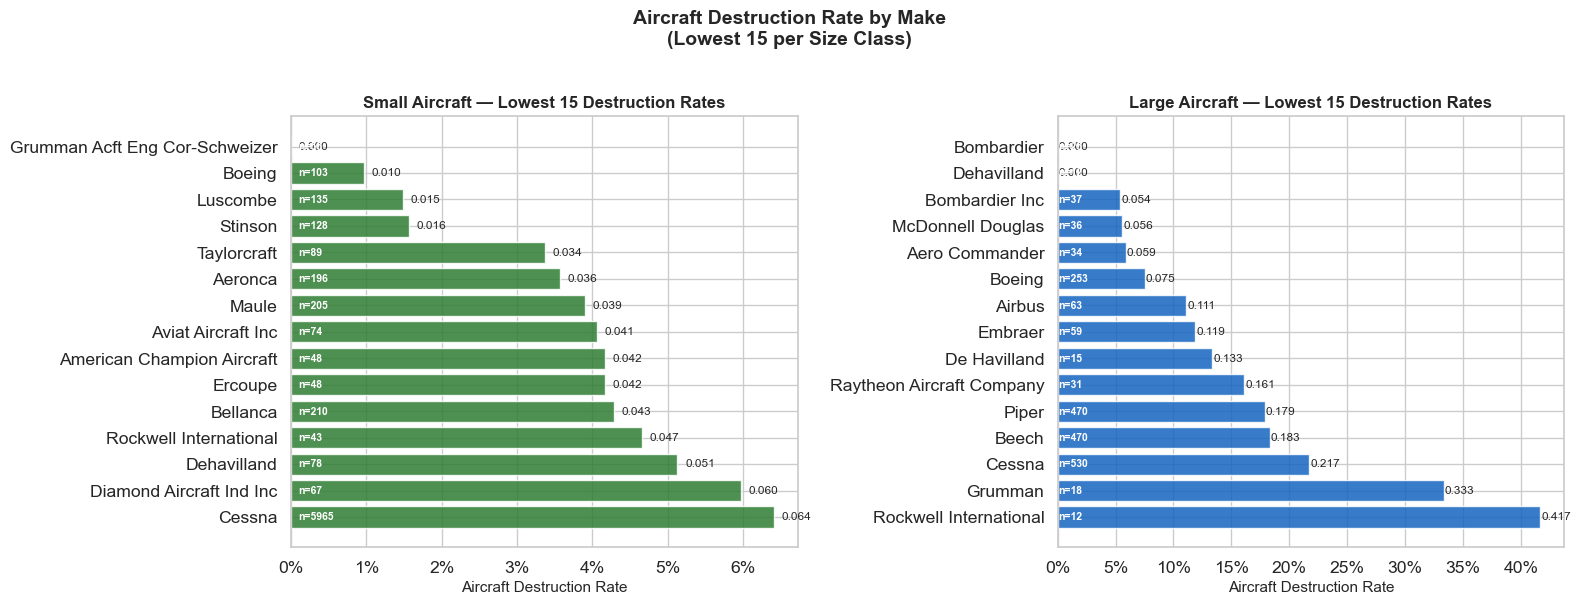

In [65]:
def dest_stats(sub, min_n=10):
    return sub.groupby('Make').agg(
        n=('is_destroyed', 'count'),
        dest_rate=('is_destroyed', 'mean')
    ).query(f'n >= {min_n}').sort_values('dest_rate').head(15)

sm_dest = dest_stats(small)
lg_dest = dest_stats(large)

print('=== Small Aircraft — Lowest 15 Destruction Rates ===')
print(sm_dest)
print('\n=== Large Aircraft — Lowest 15 Destruction Rates ===')
print(lg_dest)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ms, title, color in zip(axes,
        [sm_dest, lg_dest],
        ['Small Aircraft — Lowest 15 Destruction Rates',
         'Large Aircraft — Lowest 15 Destruction Rates'],
        ['#2E7D32', '#1565C0']):
    bars = ax.barh(ms.index[::-1], ms['dest_rate'][::-1],
                   color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Aircraft Destruction Rate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    for bar in bars:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8.5)
    for i, (make, row) in enumerate(ms[::-1].iterrows()):
        ax.text(0.001, i, f'n={int(row["n"])}',
                va='center', fontsize=7.5, color='white', fontweight='bold')

plt.suptitle('Aircraft Destruction Rate by Make\n(Lowest 15 per Size Class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Make-Level Findings

#### Small Aircraft

Among single-engine makes (n ≥ 10), Maule (μ=15.9%, n=205) and Aviat Aircraft (μ=16.7%, n=75) lead with the lowest mean fatal/serious injury rates — well below the overall mean of about 27.5%. Bellanca (μ=21.5%, n=210) and Cessna (μ=22.5%, n=5,997) round out the top tier, with Cessna's enormous sample providing the most statistically reliable estimate in this group.

The violin plots reveal a characteristic bimodal distribution across all small makes: a dominant peak at 0% (this means the majority of accidents produce no fatal/serious injuries) and a secondary peak near 100% (all-fatal events). Maule and Bellanca exhibit the widest zero-injury spike relative to their size, confirming their genuine safety advantage.

For destruction rate, Grumman Acft Eng Cor-Schweizer (0.000, n=55) is the standout. Among general-purpose manufacturers, Maule (3.9%) and Bellanca (4.3%) have the lowest destruction rates alongside competitive injury rates — a strong dual recommendation.

Small aircraft makes to recommend: Cessna (μ=22.5%, dest=6.4%), Maule (μ=15.9%, dest=3.9%), Bellanca (μ=21.5%, dest=4.3%).

#### Large Aircraft

The large-aircraft landscape is dominated by commercial jet manufacturers. Bombardier (μ=2.4%, n=25) and McDonnell Douglas (μ=2.4%, n=46) lead on injury rate. Boeing (μ=6.0%, n=398) offers the most statistically robust estimate in this group — 398 accidents with only a 6% mean injury rate represents an extraordinary safety record at scale.

The strip plots make Boeing's consistency visually clear: the majority of individual accidents cluster near 0% injury, with only rare high-severity outliers pulling the mean above zero. Bombardier shows a similar pattern but with fewer data points.

On destruction rate, Bombardier (0.000) and Boeing (7.5%) are the top performers. Beech (18.3%) and Piper (17.9%) multi-engine aircraft are considerably more likely to be destroyed in accidents.

Large aircraft makes to recommend: Boeing (μ=6.0%, dest=7.5%), Bombardier/Bombardier Inc (μ=2.4–4.2%, dest=0–5.4%), McDonnell Douglas (μ=2.4%, dest=5.6%), Airbus (μ=8.2%, dest=11.1%).

### Airplane Model Analysis

=== Small Aircraft Models — Top 10 Lowest Injury Rate (n≥10) ===
                                      n  mean_inj
Make_Model                                       
Cessna — 172SP                       12    0.0000
Diamond Aircraft Ind Inc — DA 20 C1  10    0.0000
Maule — M-5-210C                     11    0.0000
Cessna — 182N                        11    0.0227
Cessna — A185E                       16    0.0312
Cessna — 180J                        28    0.0357
Piper — PA-20                        25    0.0400
Beech — B19                          16    0.0417
Cessna — 180H                        34    0.0490
Cessna — 195                         37    0.0495

=== Large Aircraft Models — Top 10 Lowest Injury Rate (n≥10) ===
                               n  mean_inj
Make_Model                                
Boeing — 777                  12    0.0008
Boeing — 757                  13    0.0020
Bombardier Inc — CL-600-2B19  15    0.0041
Boeing — 737-7H4              13    0.0184
Embraer — E

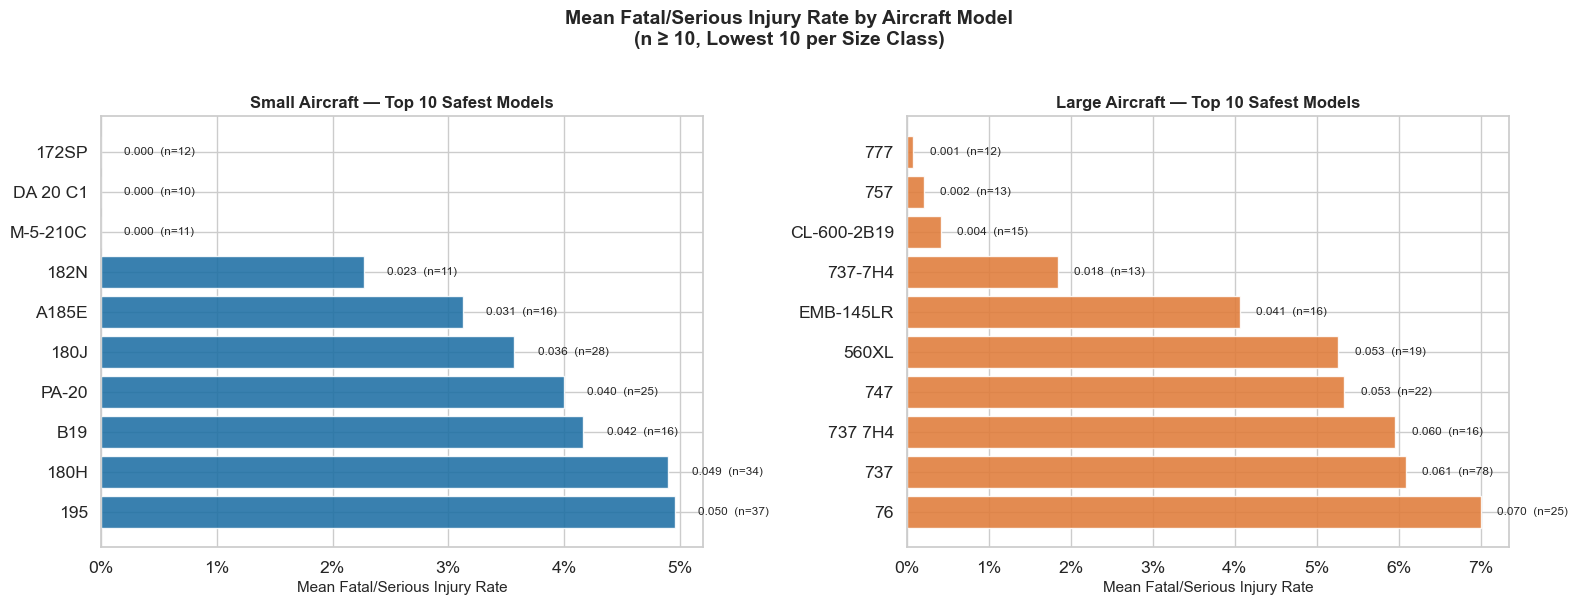

In [66]:
def model_injury_stats(sub, min_n=10):
    return sub.groupby('Make_Model').agg(
        n=('injury_rate', 'count'),
        mean_inj=('injury_rate', 'mean')
    ).query(f'n >= {min_n}').sort_values('mean_inj')

sm_models = model_injury_stats(small).head(10)
lg_models = model_injury_stats(large).head(10)

print('=== Small Aircraft Models — Top 10 Lowest Injury Rate (n≥10) ===')
print(sm_models)
print('\n=== Large Aircraft Models — Top 10 Lowest Injury Rate (n≥10) ===')
print(lg_models)

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ms, title, color in zip(axes,
        [sm_models, lg_models],
        ['Small Aircraft — Top 10 Safest Models', 'Large Aircraft — Top 10 Safest Models'],
        ['#1D6FA4', '#E07B39']):
    labels = [m.split(' — ')[1] if ' — ' in m else m for m in ms.index[::-1]]
    bars = ax.barh(labels, ms['mean_inj'][::-1].values,
                   color=color, edgecolor='white', alpha=0.88)
    ax.set_xlabel('Mean Fatal/Serious Injury Rate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    for bar, (idx, row) in zip(bars, ms[::-1].iterrows()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}  (n={int(row["n"])})',
                va='center', fontsize=8.5)

plt.suptitle('Mean Fatal/Serious Injury Rate by Aircraft Model\n(n ≥ 10, Lowest 10 per Size Class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

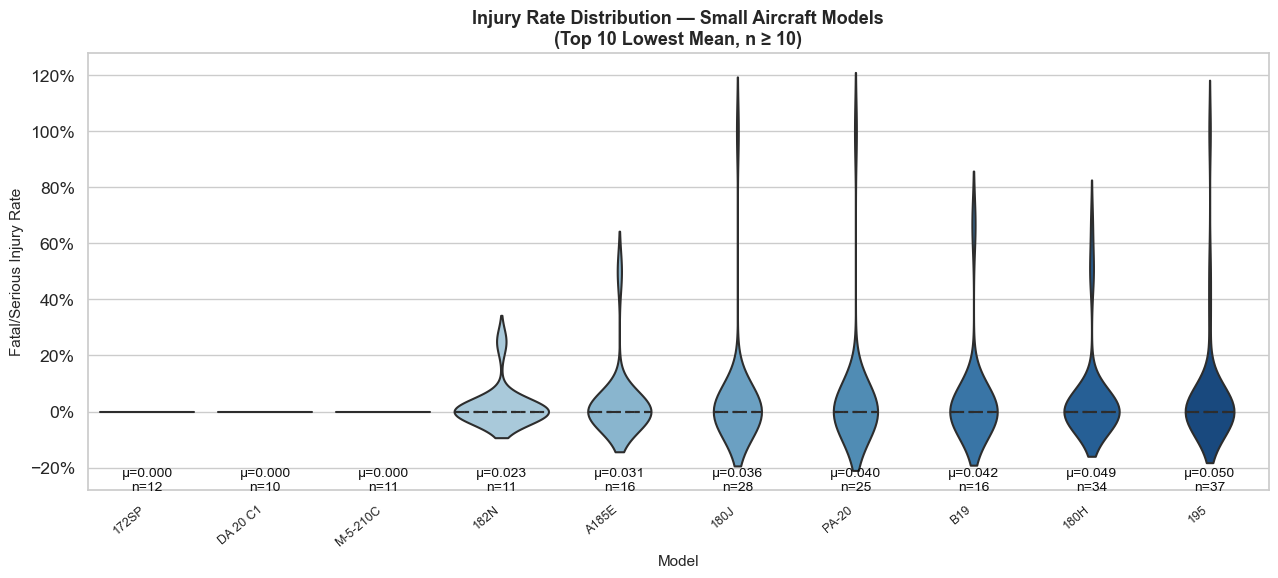

In [67]:
# Violin — small models
sm10_data = small[small['Make_Model'].isin(sm_models.index)].dropna(subset=['injury_rate']).copy()
sm10_data['Model_Label'] = sm10_data['Make_Model'].str.split(' — ').str[1]
label_order = [m.split(' — ')[1] if ' — ' in m else m for m in sm_models.index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=sm10_data, x='Model_Label', y='injury_rate', order=label_order,
               palette='Blues', inner='quartile',
               density_norm='width', legend=False, ax=ax)
ax.set_xticks(range(len(label_order)))
ax.set_xticklabels(label_order, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Injury Rate Distribution — Small Aircraft Models\n(Top 10 Lowest Mean, n ≥ 10)',
             fontsize=13, fontweight='bold')
for i, (idx, row) in enumerate(sm_models.iterrows()):
    ax.text(i, -0.2, f'μ={row["mean_inj"]:.3f}\nn={int(row["n"])}',
            ha='center', va='top', fontsize=10, color='#111')
plt.tight_layout()
plt.show()

c:\Users\steve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\steve\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


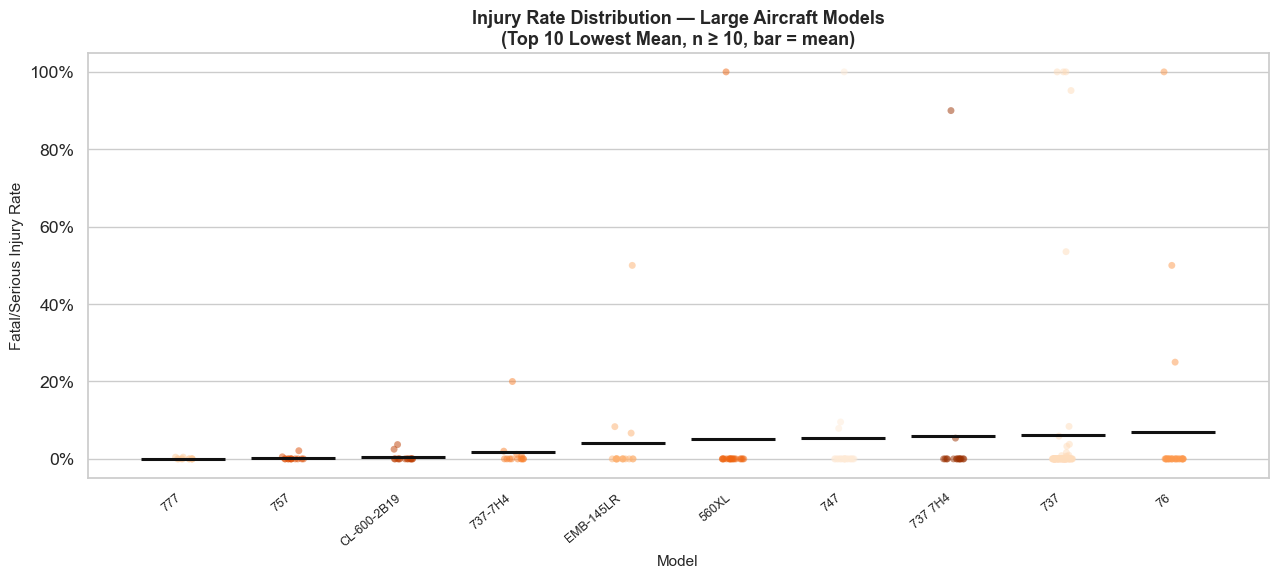

In [68]:
# Strip — large models
lg10_data = large[large['Make_Model'].isin(lg_models.index)].dropna(subset=['injury_rate']).copy()
lg10_data['Model_Label'] = lg10_data['Make_Model'].str.split(' — ').str[1]
label_order_lg = [m.split(' — ')[1] if ' — ' in m else m for m in lg_models.index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.stripplot(data=lg10_data, x='Model_Label', y='injury_rate', order=label_order_lg,
              hue='Model_Label', palette='Oranges', alpha=0.5, size=5,
              jitter=True, legend=False, ax=ax)
for i, (idx, row) in enumerate(lg_models.iterrows()):
    ax.hlines(row['mean_inj'], i - 0.38, i + 0.38, colors='#111', linewidth=2.2, zorder=5)
ax.set_xticks(range(len(label_order_lg)))
ax.set_xticklabels(label_order_lg, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Injury Rate Distribution — Large Aircraft Models\n(Top 10 Lowest Mean, n ≥ 10, bar = mean)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Specific Airplane Models

#### Small Aircraft Models

Three models achieve a 0% mean fatal/serious injury rate across at least 10 recorded accidents: the Cessna 172SP (n=12), Diamond DA 20 C1 (n=10), and Maule M-5-210C (n=11). While the sample size is low, zero injuries across all recorded accidents is still a good safety signal.

The Cessna A185E (n=16, μ=3.1%), Cessna 180J (n=28, μ=3.6%), Piper PA-20 (n=25, μ=4.0%), and Cessna 195 (n=37, μ=5.0%) all combine low injury rates with meaningful sample sizes. The Cessna 195 (n=37) is the best-validated low-injury small aircraft model in this dataset.

The violin plots confirm the signal: the Cessna 172SP, Maule M-5-210C, and Diamond DA 20 have all their probability mass at 0% (survivable accidents). Models further down the list show the characteristic bimodal structure with a growing second peak near 100%, which indicates a small fraction of catastrophic events.

Small model top picks: Cessna 195 (best validation), Cessna 180J/180H (low injury + reasonable sample size), Piper PA-20 (low injury, n=25), Cessna A185E. The Cessna 172SP is also a strong candidate.

#### Large Aircraft Models

The Boeing 777 (n=12, μ=0.08%) and Boeing 757 (n=13, μ=0.20%) are almost perfect from an injury standpoint — less than 1 injured passenger per 500 involved in accidents. The Bombardier CL-600-2B19 (CRJ regional jet, n=15, μ=0.41%) follows closely.

The Boeing 737 (n=78, μ=6.1%) provides the most statistically meaningful estimate given its large sample size. Despite a higher rate, 6.1% remains extraordinarily low for its sample size and the strip plot shows majority of its 737 accidents produce zero fatalities/serious injuries — only a few high-severity outlier events elevate the mean.

The Beech 76 (n=25, μ=7.0%) appears in the large-aircraft top 10 but its appearance here is partly explained by the controlled training environment (airports, instructors) that helps contain accident severity.

Large model top picks: Boeing 777, Boeing 757 (outstanding but lower sample size), Bombardier CL-600-2B19. For the most statistically robust recommendation: Boeing 737 n=78, μ=6.1%, is well-validated.

## Exploring Other Variables

### Weather Condition (VMC (good visibility) vs IMC (poor visibility))

Hypothesis: Accidents occurring in poor-visibility IMC conditions (clouds, precipitation, fog) produce significantly more severe outcomes than those in clear VMC conditions.

In [69]:
wdf = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

wc_stats = wdf.groupby('Weather.Condition').agg(
    n_total=('Weather.Condition', 'count'),
    mean_inj=('injury_rate', 'mean'),
    median_inj=('injury_rate', 'median'),
    dest_rate=('is_destroyed', 'mean')
).round(4)
print('Weather Condition Summary Statistics:')
print(wc_stats)

# Chi-square: weather vs. destruction
ct = pd.crosstab(
    wdf.dropna(subset=['is_destroyed'])['Weather.Condition'],
    wdf.dropna(subset=['is_destroyed'])['is_destroyed']
)
chi2_stat, p_chi2, dof, _ = chi2_contingency(ct)

# Mann-Whitney: VMC vs IMC injury rates
vmc_inj = wdf[wdf['Weather.Condition'] == 'VMC']['injury_rate'].dropna()
imc_inj = wdf[wdf['Weather.Condition'] == 'IMC']['injury_rate'].dropna()
u_stat, p_mw = mannwhitneyu(vmc_inj, imc_inj, alternative='less')

print(f'\nChi-square (weather vs. destruction): χ²={chi2_stat:.1f}, p={p_chi2:.2e}')
print(f'Mann-Whitney U (VMC inj < IMC inj):   U={u_stat:.0f},   p={p_mw:.2e}')
print('Both tests are statistically overwhelming (p << 0.001)')

Weather Condition Summary Statistics:
                   n_total  mean_inj  median_inj  dest_rate
Weather.Condition                                          
IMC                    905    0.6280      1.0000     0.3676
VMC                  14295    0.2331      0.0000     0.0724

Chi-square (weather vs. destruction): χ²=859.9, p=5.20e-189
Mann-Whitney U (VMC inj < IMC inj):   U=3580757,   p=1.41e-165
Both tests are statistically overwhelming (p << 0.001)


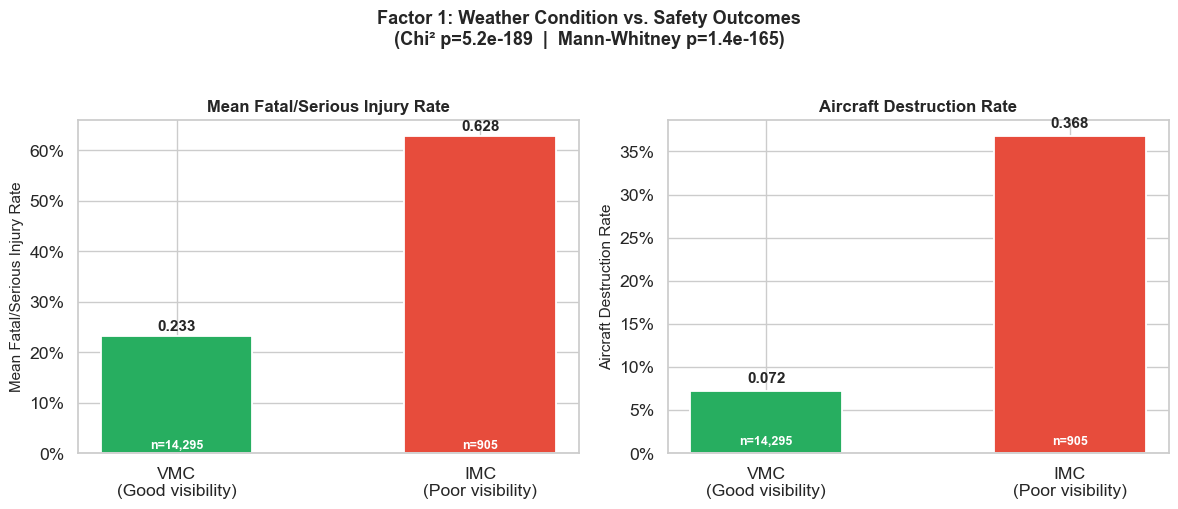

In [70]:
colors_wc = {'VMC': '#27AE60', 'IMC': '#E74C3C'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
        ['mean_inj', 'dest_rate'],
        ['Mean Fatal/Serious Injury Rate', 'Aircraft Destruction Rate']):
    vals = wc_stats.loc[['VMC', 'IMC'], col]
    bars = ax.bar(['VMC\n(Good visibility)', 'IMC\n(Poor visibility)'],
                  vals.values,
                  color=[colors_wc['VMC'], colors_wc['IMC']],
                  edgecolor='white', linewidth=1.3, width=0.5)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    for bar, cond in zip(bars, ['VMC', 'IMC']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', fontweight='bold', fontsize=11)
        n = int(wc_stats.loc[cond, 'n_total'])
        ax.text(bar.get_x() + bar.get_width()/2, 0.01,
                f'n={n:,}', ha='center', fontsize=9,
                color='white', fontweight='bold')

plt.suptitle(
    f'Factor 1: Weather Condition vs. Safety Outcomes\n'
    f'(Chi² p={p_chi2:.1e}  |  Mann-Whitney p={p_mw:.1e})',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

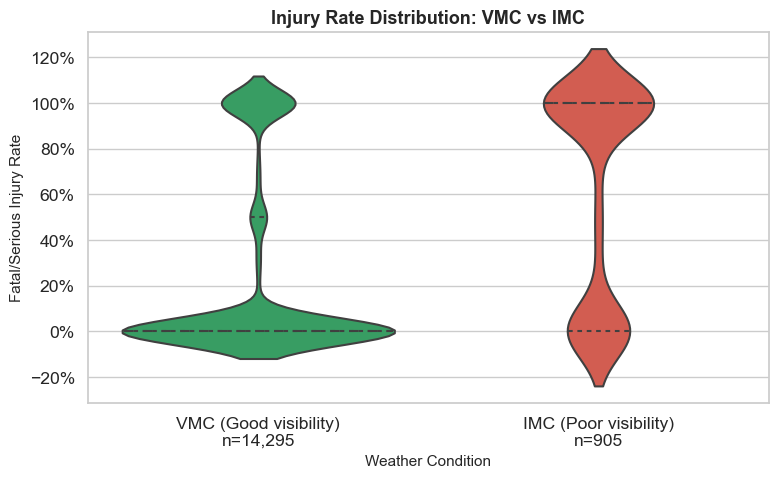

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=wdf.dropna(subset=['injury_rate']),
    x='Weather.Condition', y='injury_rate', order=['VMC', 'IMC'],
    palette=[colors_wc['VMC'], colors_wc['IMC']],
    inner='quartile', legend=False, ax=ax
)
ax.set_xlabel('Weather Condition', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Injury Rate Distribution: VMC vs IMC', fontsize=13, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['VMC (Good visibility)\nn=14,295',
                    'IMC (Poor visibility)\nn=905'])
plt.tight_layout()
plt.show()

#### Weather Condition

The relationship between weather and accident severity:

The median IMC injury rate is 100% — in more than half of IMC accidents, every single occupant suffered a fatal or serious injury. The VMC median is 0% — most VMC accidents produce no fatal/serious injuries at all. The two distributions are almost similar (violin plot), with VMC dominated by a mass at 0 and IMC dominated by a mass at 1.0.

Both statistical tests confirm this. The chi-square test for the destruction/weather relationship (χ²=859.9, p=5.2×10⁻¹⁸⁹) and the Mann-Whitney test for injury rates (p=1.4×10⁻¹⁶⁵) represent really extreme p-values achievable in a dataset of this size.

Mechanism: IMC forces reliance on instruments alone, removing the spatial awareness that pilots use to avoid terrain, other aircraft, and hazardous conditions. IMC-specific accident types such as spatial disorientation are among the most fatal.

### Phase of Flight

Hypothesis: High-energy flight phases (maneuvering, climb) produce worse outcomes than lower-speed phases (landing, taxi) due to higher kinetic energy at impact.

In [73]:
phases = ['Maneuvering','Climb','Descent','Approach','Cruise',
          'Takeoff','Standing','Go-around','Taxi','Landing']
pof_df = df[df['Broad.phase.of.flight'].isin(phases)].copy()

pof_stats = pof_df.groupby('Broad.phase.of.flight').agg(
    n=('Broad.phase.of.flight', 'count'),
    mean_inj=('injury_rate', 'mean'),
    median_inj=('injury_rate', 'median'),
    dest_rate=('is_destroyed', 'mean')
).reindex(phases).dropna().sort_values('mean_inj', ascending=False)

print('Phase of Flight Statistics (sorted by mean injury rate):')
print(pof_stats.round(3))

groups = [pof_df[pof_df['Broad.phase.of.flight'] == p]['injury_rate'].dropna().values
          for p in pof_stats.index]
h_stat, p_kw = kruskal(*groups)
print(f'\nKruskal-Wallis across phases: H={h_stat:.1f}, p={p_kw:.2e}')

Phase of Flight Statistics (sorted by mean injury rate):
                          n  mean_inj  median_inj  dest_rate
Broad.phase.of.flight                                       
Maneuvering             127    0.3590      0.0000     0.2910
Climb                    52    0.3180      0.0000     0.3000
Descent                  62    0.2220      0.0000     0.1750
Approach                210    0.2130      0.0000     0.1110
Cruise                  238    0.1830      0.0000     0.1380
Takeoff                 425    0.1090      0.0000     0.1060
Standing                 35    0.0940      0.0000     0.0710
Go-around                81    0.0870      0.0000     0.0620
Taxi                     99    0.0170      0.0000     0.0110
Landing                1110    0.0080      0.0000     0.0130

Kruskal-Wallis across phases: H=348.1, p=1.57e-69


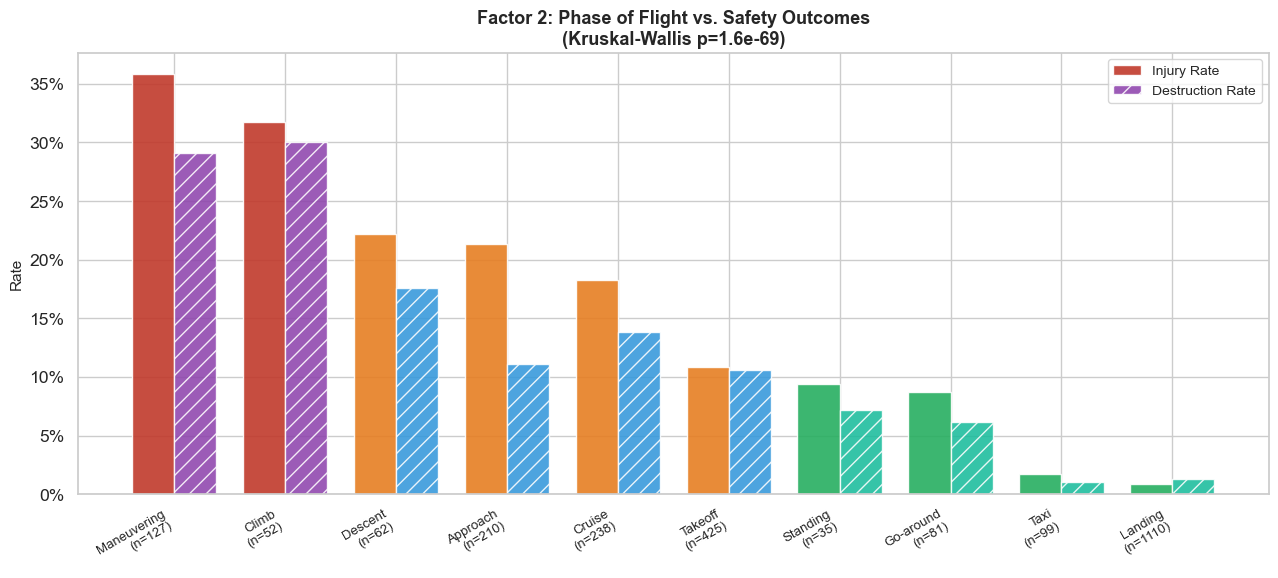

In [74]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(pof_stats))
w = 0.38

inj_colors = ['#C0392B' if v > 0.25 else ('#E67E22' if v > 0.10 else '#27AE60')
              for v in pof_stats['mean_inj']]
dest_colors = ['#8E44AD' if v > 0.20 else ('#3498DB' if v > 0.08 else '#1ABC9C')
               for v in pof_stats['dest_rate']]

ax.bar(x - w/2, pof_stats['mean_inj'], width=w,
       label='Injury Rate', color=inj_colors, edgecolor='white', alpha=0.90)
ax.bar(x + w/2, pof_stats['dest_rate'], width=w,
       label='Destruction Rate', color=dest_colors, edgecolor='white',
       alpha=0.88, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{p}\n(n={int(pof_stats.loc[p, "n"])})' for p in pof_stats.index],
    rotation=30, ha='right', fontsize=9.5)
ax.set_ylabel('Rate', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title(
    f'Factor 2: Phase of Flight vs. Safety Outcomes\n'
    f'(Kruskal-Wallis p={p_kw:.1e})',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

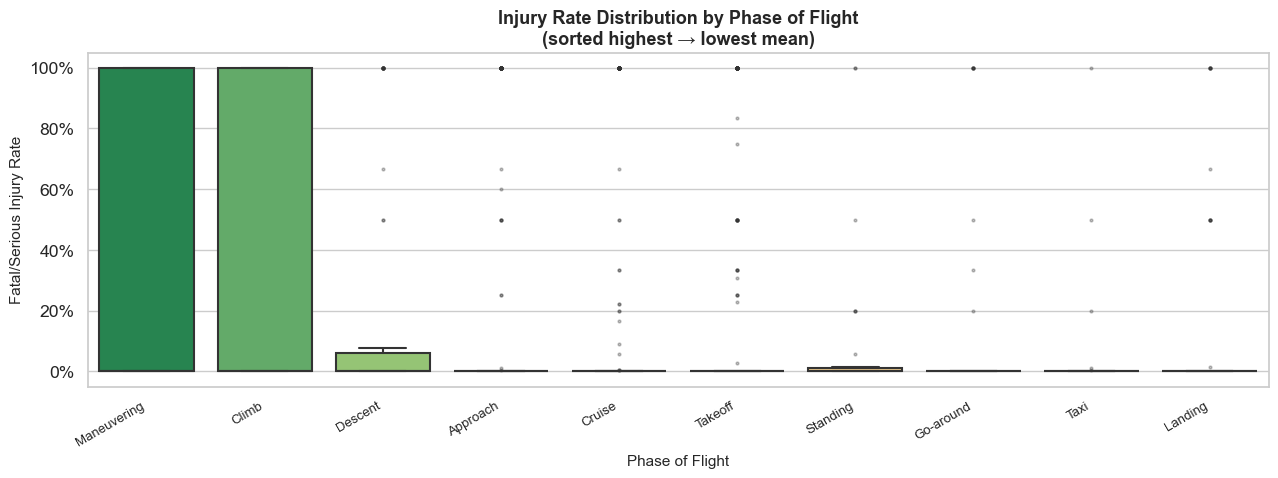

In [77]:
pof_clean = pof_df[pof_df['Broad.phase.of.flight'].isin(pof_stats.index)]\
            .dropna(subset=['injury_rate'])

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=pof_clean, x='Broad.phase.of.flight', y='injury_rate',
    order=pof_stats.index.tolist(),
    palette='RdYlGn_r',
    ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax.set_xticks(range(len(pof_stats)))
ax.set_xticklabels(pof_stats.index.tolist(), rotation=30, ha='right', fontsize=9.5)
ax.set_xlabel('Phase of Flight', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Rate', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Injury Rate Distribution by Phase of Flight\n(sorted highest → lowest mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Phase of Flight

The data follow a clear physical pattern: kinetic energy at impact determines survivability.

Maneuvering (35.9% injury, 29.1% destruction) and Climb (31.8%, 30.0%) are the most deadly phases. Maneuvering accidents frequently involve loss of control at altitude. Climb accidents often result from engine failure with insufficient altitude for recovery or loss of control after takeoff — both leave minimal survival margin.

Landing is by far the safest phase despite being the most frequent accident phase (n=1,110). Mean injury rate is only 0.8% and destruction rate 1.3%. A gear collapse or runway excursion at 70 knots is way more survivable than a loss-of-control event at 200 knots.

The box plots make distribution differences vivid. The Landing box sits essentially at 0 with almost no spread — nearly all accidents produce zero fatalities/serious injuries. Maneuvering and Climb boxes are elevated, with medians well above 0 and wide interquartile ranges. The Kruskal-Wallis test confirms the differences are statistically significant (H=348.1, p=1.6×10⁻⁶⁹).